# day 36 | 251121 F

## hitherto

We have previously used the following function to calculate the second derivative at a particular place. We will be using this in the following discussion about solving these differential equations.

```python
def d2(function, x_value, stepSize):
    return (function(x_value+stepSize)-2*function(x_value)+function(x_value-stepSize))/(stepSize**2)
```
## herein

We are going to look at the heat equation, also known as the diffusion equation. The method to solve this partial differential equation is known as *Forward-Time Centered-Space* Method, or *FTCS* for short. What this means is actually very simple, we are going to solve for the temperature along a rod as time is ticking by. The amount that the temperature is going to advance is equal to the second derivative of how the temperature is arranged over space. This will continue until the second derivative is zero, which means that the temperature is no longer changing along the rod. The PDE for this is the equation:

$$\frac{\partial^2 T}{\partial x^2} = \frac{d T}{d t} $$

The boundary conditions for this PDE are simply the temperatures that this is being held at the two ends. We know that eventually the temperature will change in a linear fashion along this length (\\(\frac{\partial^2 T}{\partial x^2} = 0\\)), but we are also curious about how this changes over time. So what we will do is code up a method for solving this as time is ticking by and then save a few of these temperature profiles to plot at some interesting times.

I would like for you to solve exercise 9.4. 

## hence

We need to move on to the wave partial differential equation, but I think first we need to pick up some matrix stuff and some fourier stuff and then we will come back and try to hit the wave equation and Schrodinger's equation last. 

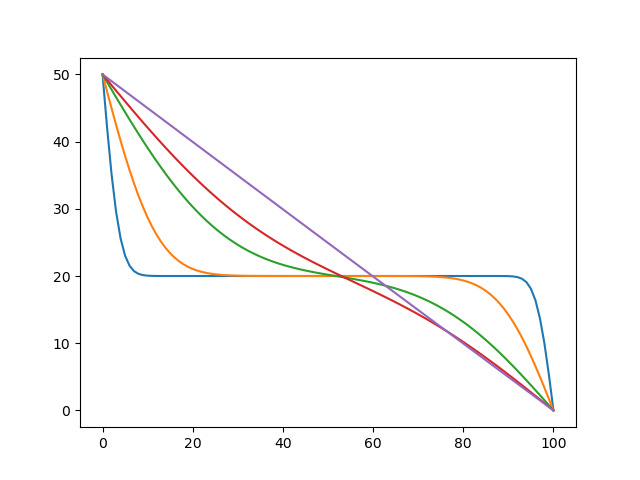

In [10]:
L = 0.01
N = 100
dx = L/N

dt = 1e-4

D = 4.25e-6
c = D*dt/dx**2

# boundary conditions
Tlow = 0.0
Thi = 50.0
Ti = 20.0

T = np.ones(N+1)*Ti
T[0] = Thi
T[-1] = Tlow

# Tp = np.empty(N+1)
# ok that caused a big problem
# just make Tp a copy of T initially
# and then we'll update them as we go along
Tp = T.copy()

times = [0.01, 0.1, 0.5, 1.0, 10.0]
snapshots = []

t = 0.0

for target in times:
    while t<target:
        # forward-time centered-space method (FTCS)
        for i in range(1,N): # loops over the length of the rod
           Tp[i] = T[i] + c*(T[i+1]+T[i-1]-2*T[i])
        # T, Tp = Tp, T # might need to change we'll see
        T = Tp
        t += dt
        # Below is a fancy way to do it without any Tp business
        # but it is harder to understand what is happening
        # Essentially, I am shifting the matrix forward 
        # and then also shifting it backward, and adding the
        # results together, and taking away the entirety of 
        # what it was before. Is that clear? Good.
        # T[1:-1] += c*(T[2:] + T[:-2] - 2*T[1:-1])
        # t += dt
    snapshots.append(T.copy())

fig0, ax0 = plt.subplots()
for profile in snapshots:
    ax0.plot(profile)